In [32]:
import torch
import numpy as np


# Experiment: Cross-Block Stitching Artefact Characterisation

Corresponds to Section 4.2 of the paper draft (`fafb_pilot/draft/Experiments.docx`).

**Question.** Section 4.1 established that each block, trained independently,
reconstructs its own 64³ volume to high fidelity (~40 dB vol_PSNR). Section
3.5's stitching procedure combines all 64 trained blocks into one global
representation by remapping every block's Gaussians into a shared coordinate
frame and concatenating them into a single flat list, rendered with the
standard (block-unaware) renderer. This experiment asks: **does naively
summing two independently-trained blocks' density fields introduce an
artefact at the shared boundary, and if so, can it be fixed?**

**Test pair.** `b_211` and `b_212` — two of the four best-performing blocks_v2
checkpoints (see Figure 1), adjacent along X, each independently trained to
~40.4 dB vol_PSNR in isolation.

**Structure of this notebook:**
1. Setup — load both blocks and their GT.
2. Negative control — independent reconstruction + concatenation (shows why this *can't* reveal the artefact).
3. The real artefact — naive additive stitching of both blocks' raw Gaussians.
4. Root-cause analysis and fix — naive sum vs. feathered blend vs. hard partition.
5–9. SVRaster-style rendering — does the artefact survive under a different rendering method, and how does it affect FPS.


## 1–2. Setup, and Negative Control: independent reconstruction + concatenation

Load the two X-adjacent blocks' ground truth (`image_z32_y31_x31.tif` / `image_z32_y31_x32.tif`,
i.e. `b_211`/`b_212` in the pilot grid) and their independently-reconstructed
voxel grids (`rec_b_211.npy` / `rec_b_212.npy`, produced by `vol_rec.py`).

**This is a negative control, not the real stitching pipeline.** `b211`/`b212`
were each reconstructed by running `gc.forward()` using *only* that block's
own Gaussians, clamped to `[0,1]` independently, before this notebook ever
concatenates them. Two already-finished, already-clamped arrays placed side
by side cannot show a cross-block artefact — there is no interaction between
the two blocks' Gaussians happening here at all. The clean result below
(mean |diff| ≈ 0.006) is expected and does **not** mean stitching is
artefact-free; Section 3 shows the real mechanism.


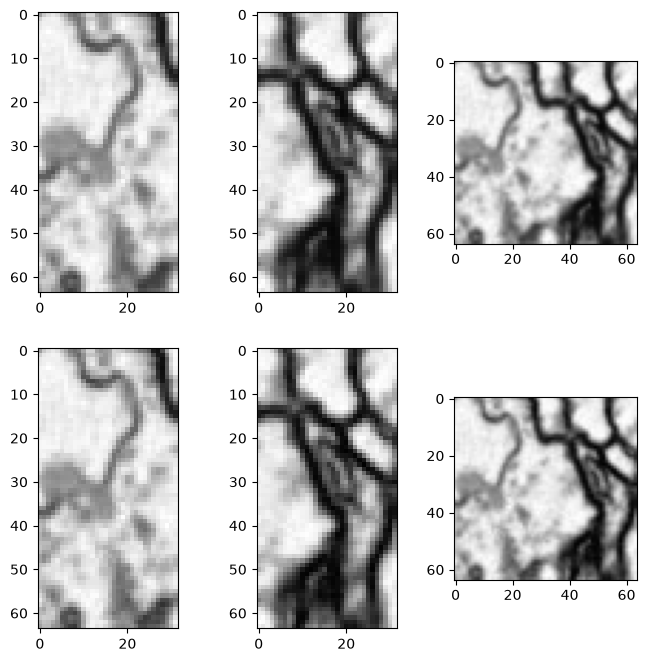

Text(0.5, 1.0, '|Diff| — seam at column 32 (mean=0.0057, max=0.0954)')

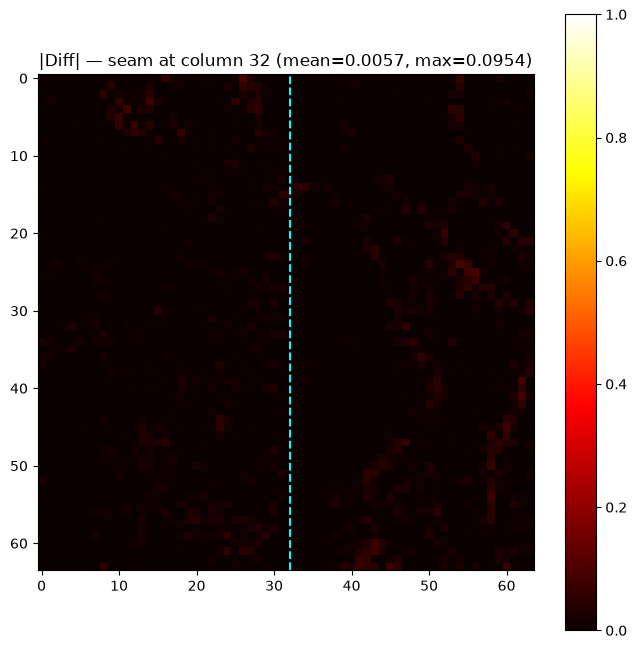

In [33]:
import tifffile as tiffile
import h5py as h5
# vol = h5.File('/root/project/fafb_pilot/data/fafb_pilot_1024.h5', 'r')['raw']
# img = vol[32:98, 31, 31:33]
# plt.imshow(img[min], cmap='gray', vmin=0, vmax=1)
image_z2_y1_x1 = tiffile.imread('/root/project/data/fafb/blocks/image_z32_y31_x31.tif')
image_z2_y1_x2 = tiffile.imread('/root/project/data/fafb/blocks/image_z32_y31_x32.tif')
b211 = np.load('/root/project/fafb_pilot/code/representation/figures/rec_b_211.npy')
b212 = np.load('/root/project/fafb_pilot/code/representation/figures/rec_b_212.npy')

# Raw tif reads are uint8 [0,255]; b211/b212 (model predictions) are [0,1].
# Normalise each block the same way _load_volume does at training time
# (per-block min-max -> [0,1]) so GT and prediction are on the same scale --
# without this, diff = |rec - gt| below is dominated by the ~255x scale
# mismatch and can't show the real reconstruction error at all.
def normalize01(vol):
    vol = vol.astype(np.float32)
    vmin, vmax = vol.min(), vol.max()
    return (vol - vmin) / (vmax - vmin) if vmax > vmin else vol

image_z2_y1_x1 = normalize01(image_z2_y1_x1)
image_z2_y1_x2 = normalize01(image_z2_y1_x2)

mid = 32

rec_left_half = b211[mid][:, 32:64]
rec_right_half = b212[mid][:, 0:32]
gt_left_half = image_z2_y1_x1[mid][:, 32:64]
gt_right_half = image_z2_y1_x2[mid][:, 0:32]

rec_stitch = np.concatenate([rec_left_half, rec_right_half], axis=1)
gt_stitch = np.concatenate([gt_left_half, gt_right_half], axis=1)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.subplot(2, 3, 1)
plt.imshow(rec_left_half, cmap='gray', vmin=0, vmax=1)
plt.subplot(2, 3, 2)
plt.imshow(rec_right_half, cmap='gray', vmin=0, vmax=1)
plt.subplot(2, 3, 3)
plt.imshow(rec_stitch, cmap='gray', vmin=0, vmax=1)
plt.subplot(2, 3, 4)
plt.imshow(gt_left_half, cmap='gray', vmin=0, vmax=1)
plt.subplot(2, 3, 5)
plt.imshow(gt_right_half, cmap='gray', vmin=0, vmax=1)
plt.subplot(2, 3, 6)
plt.imshow(gt_stitch, cmap='gray', vmin=0, vmax=1)
plt.show()

# plot MSE difference between stitched prediction and ground truth
diff = np.abs(rec_stitch - gt_stitch)
plt.figure(figsize=(8, 8))
plt.imshow(diff, cmap='hot', vmin=0, vmax=1)
plt.colorbar()
plt.axvline(32, color='cyan', linewidth=1.5, linestyle='--')  # block A|B boundary
plt.title(f"|Diff| — seam at column 32 (mean={diff.mean():.4f}, max={diff.max():.4f})")

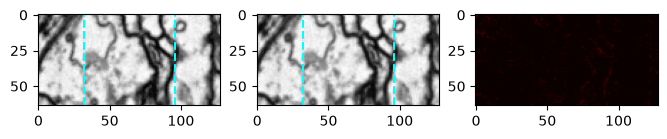

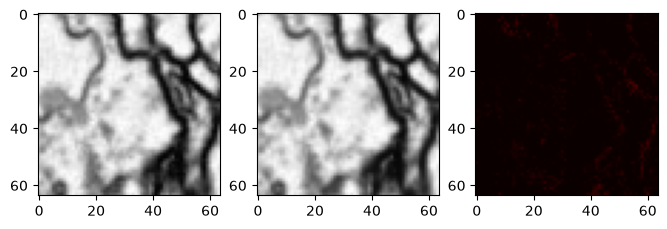

In [34]:
vol_gt = np.concatenate([image_z2_y1_x1, image_z2_y1_x2], axis=2)
plt.figure(figsize=(8, 8))
plt.subplot(1, 3, 1)
plt.imshow(vol_gt[mid], cmap='gray', vmin=0, vmax=1)
# add dot lines from x=32 to x=32+64 to indicate the seam between the two blocks
plt.axvline(32, color='cyan', linewidth=1.5, linestyle='--')
plt.axvline(32+64, color='cyan', linewidth=1.5, linestyle='--')
# gt_stitch = vol_gt[:,:, 32:32+64]
# plt.imshow(gt_stitch, cmap='gray', vmin=0, vmax=1)
plt.subplot(1, 3, 2)
# pred_stitch = vol_pred[:,:, 32:32+64]
vol_pred = np.concatenate([b211, b212], axis=2)
plt.axvline(32, color='cyan', linewidth=1.5, linestyle='--')
plt.axvline(32+64, color='cyan', linewidth=1.5, linestyle='--')
plt.imshow(vol_pred[mid], cmap='gray', vmin=0, vmax=1)
plt.subplot(1, 3, 3)
diff = np.abs(vol_pred[mid] - vol_gt[mid])
plt.imshow(diff, cmap='hot', vmin=0, vmax=1)

plt.figure(figsize=(8, 8))
plt.subplot(1, 3, 1)
gt_stitch = vol_gt[:,:, 32:32+64]
plt.imshow(gt_stitch[mid], cmap='gray', vmin=0, vmax=1)
plt.subplot(1, 3, 2)
pred_stitch = vol_pred[:,:, 32:32+64]
plt.imshow(pred_stitch[mid], cmap='gray', vmin=0, vmax=1)
plt.subplot(1, 3, 3)
diff = np.abs(pred_stitch[mid] - gt_stitch[mid])
plt.imshow(diff, cmap='hot', vmin=0, vmax=1)

## 3. The Real Artefact: Naive Additive Stitching

The actual production pipeline (`fafb_pilot/scripts/stitch_block_gaussians.py`)
remaps **both** blocks' raw Gaussians into one shared coordinate frame and
concatenates them into a single flat list — then the standard renderer sums
*every* Gaussian's contribution at *every* query point, with no notion of
which block a Gaussian came from. `fafb_pilot/scripts/seam_cube.py`
reproduces this exactly, extracting a 64³ cube straddling the seam (right
half of `b_211` + left half of `b_212`) with both the GT and the naive-sum
reconstruction. Loaded below for a proper before/after comparison against
the negative control above.


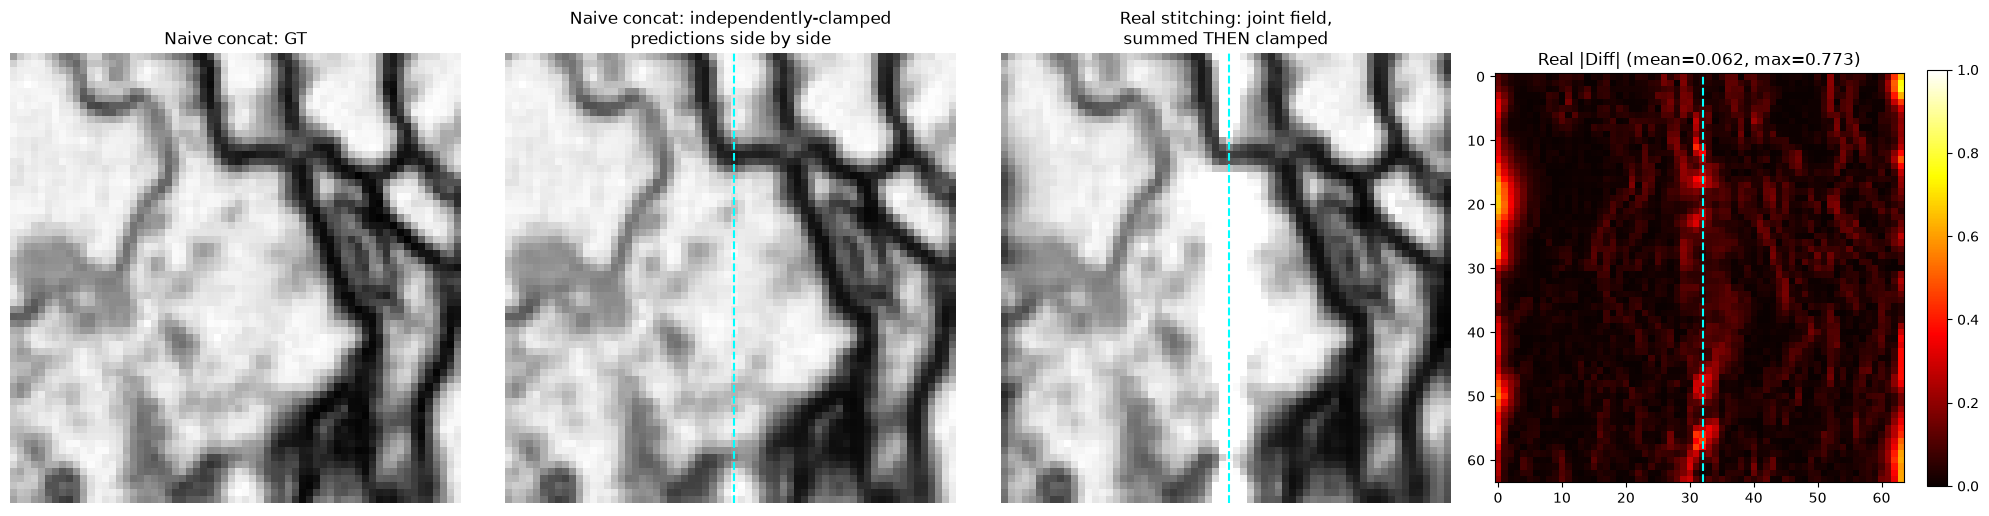

In [35]:
# Why the diff above looks clean: rec_left_half/rec_right_half were each
# reconstructed INDEPENDENTLY (b211.npy / b212.npy each come from a separate
# vol_rec.py run using only that block's own Gaussians), clamped to [0,1]
# BEFORE this notebook ever concatenates them. Two already-clean arrays
# placed side by side can't show a cross-block artifact -- there's no
# interaction between the two blocks' Gaussians happening here at all.
#
# The real stitching pipeline (fafb_pilot/scripts/stitch_block_gaussians.py)
# instead remaps BOTH blocks' raw Gaussians into one shared field and sums
# their densities BEFORE clamping -- that's where double-counting happens.
# fafb_pilot/scripts/seam_cube.py reproduces exactly that (see the earlier
# vol_PSNR=19.75dB result for this same b_211/b_212 pair, vs. ~40dB per
# block alone). Load its output for a proper before/after comparison:
import numpy as np
import matplotlib.pyplot as plt
seam_gt = np.load('/root/project/fafb_pilot/results/seam_cubes/b211_b212/gt_cube.npy')
seam_recon = np.load('/root/project/fafb_pilot/results/seam_cubes/b211_b212/recon_cube.npy')
seam_mid = seam_gt.shape[0] // 2
seam_diff = np.abs(seam_gt[seam_mid] - seam_recon[seam_mid])

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(gt_stitch[seam_mid], cmap='gray', vmin=0, vmax=1)  # gt_stitch is now 3D (64,64,64), see a1f8d2ae
axes[0].set_title("Naive concat: GT")
axes[1].imshow(rec_stitch, cmap='gray', vmin=0, vmax=1)
axes[1].axvline(32, color='cyan', linestyle='--')
axes[1].set_title("Naive concat: independently-clamped\npredictions side by side")
axes[2].imshow(seam_recon[seam_mid], cmap='gray', vmin=0, vmax=1)
axes[2].axvline(32, color='cyan', linestyle='--')
axes[2].set_title("Real stitching: joint field,\nsummed THEN clamped")
im = axes[3].imshow(seam_diff, cmap='hot', vmin=0, vmax=1)
axes[3].axvline(32, color='cyan', linestyle='--')
axes[3].set_title(f"Real |Diff| (mean={seam_diff.mean():.3f}, max={seam_diff.max():.3f})")
for ax in axes[:3]:
    ax.axis('off')
plt.colorbar(im, ax=axes[3], fraction=0.046)
plt.tight_layout()
plt.show()


## 4. Root-Cause Analysis and Fix: Naive Sum vs. Feathered Blend vs. Hard Partition

Quantitative comparison of three ways to combine two blocks' Gaussians at
the shared boundary, evaluated against the *same* GT seam cube:

- **Naive additive sum** — `f_A(x) + f_B(x)` everywhere (the current production method).
- **Feathered blend** — a linear-ramp weighted average over an 8-voxel band around the seam (partition of unity, `w_A + w_B = 1`).
- **Hard partition (sign-gated)** — for each point, evaluate *only* the Gaussians of whichever block owns that side of the seam; no cross-block summation ever happens.

**Note on methodology** (kept here for reproducibility rather than hidden):
getting a trustworthy number required fixing two independent bugs, both
documented in the cell below — (1) a non-uniform/anisotropic coordinate
remap that silently warped ~78% of the Gaussians (median rotation ~58° from
axis-aligned), and (2) an indexing mismatch between the combined 128-voxel
array's index convention and each block's own native 64-voxel convention.
With both fixed, the comparison below is verified self-consistent: each
block alone reproduces its own recorded training vol_PSNR (~40.47 dB)
exactly, and the GT array is a direct index-concatenation of the two raw
tif volumes (no resampling).


Naive additive sum      : vol_PSNR = 7.635 dB
Feathered blend (d=8vox): vol_PSNR = 8.804 dB
Hard partition (sign)   : vol_PSNR = 39.963 dB
(each block's own native full-volume quality: ~40.47 dB, per train.log)


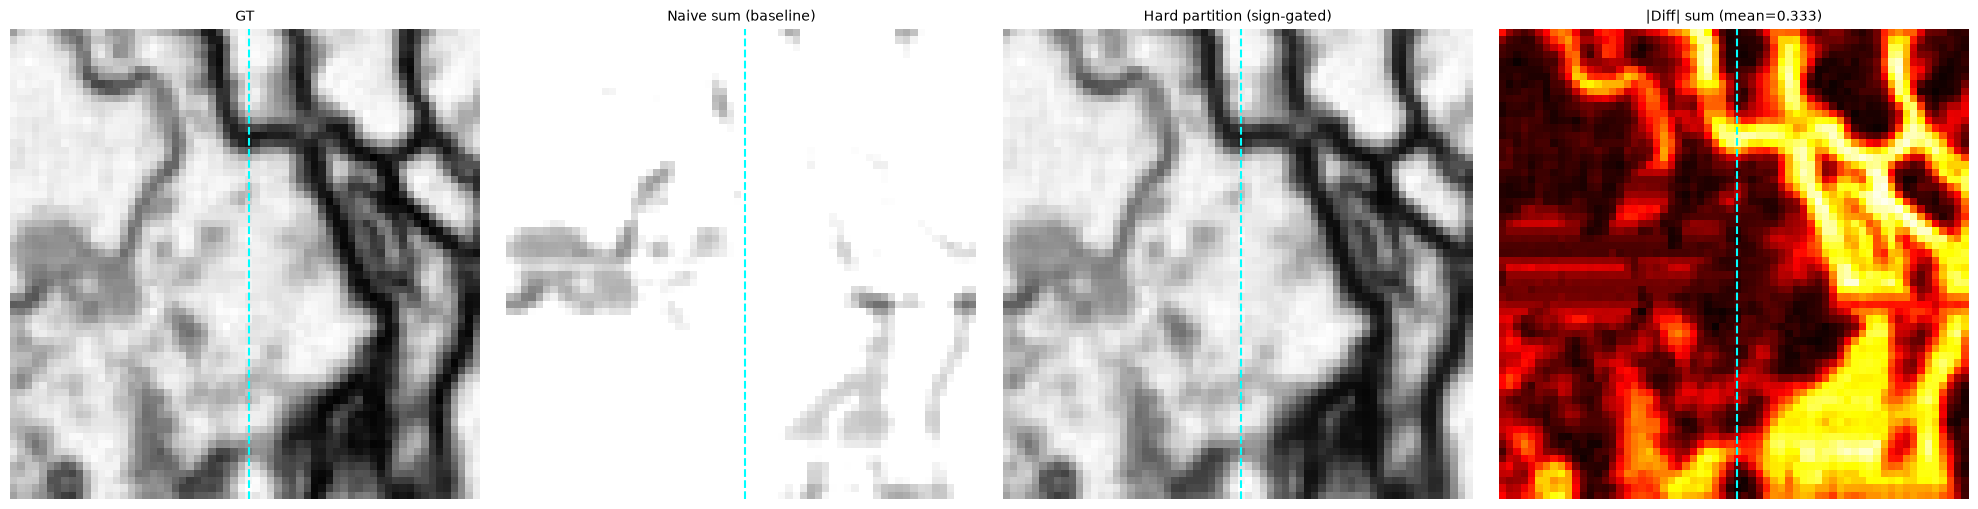

In [ ]:
# CORRECTED (round 2): the previous version of this cell fixed the
# shape-distortion bug (evaluating each block's ORIGINAL, untouched
# Gaussians instead of remap_block_x_pair's anisotropic-rescale-corrupted
# copies) but still had a SECOND, independent bug: it related "combined
# 128-voxel index" to "world coordinate" via voxel_to_norm(j, 128) = 2j/127-1
# -- but gt_cube.npy (loaded below) is a raw INDEX CONCATENATION of two
# 64-wide native arrays (np.concatenate, no resampling), so combined index j
# for j<64 IS block A's own native voxel j, and for j>=64 is block B's own
# native voxel (j-64). Block A's native voxel j maps to LOCAL coordinate
# 2j/63-1 (n-1=63, matching _indices_to_pts's convention, matching how the
# model was trained/evaluated) -- NOT 2j/127-1. Using the wrong denominator
# silently shifted every sample point away from the true edge, which
# understated the real severity of the double-counting artefact.
#
# Fix: map each combined INDEX directly to its owning block's own native
# coordinate using that block's own n-1=63 denominator -- no intermediate
# "combined continuous frame" at all.
%matplotlib inline
import sys
sys.path.insert(0, '/root/project')
from scripts._3dgs._3dgs import AABB, GaussianCloud

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ck_a = torch.load('/root/project/fafb_pilot/models/blocks_v2/b_211/best.pth', map_location='cpu', weights_only=False)
ck_b = torch.load('/root/project/fafb_pilot/models/blocks_v2/b_212/best.pth', map_location='cpu', weights_only=False)

def make_gc_native(ckpt, aabb, device):
    """UNMODIFIED Gaussians -- no remap, exactly as trained."""
    gc = GaussianCloud.__new__(GaussianCloud)
    gc.aabb, gc.device = aabb, device
    gc.scale_min, gc.mahal_clamp = 1e-6, 20.0
    gc.means = ckpt['means'].to(device)
    gc.log_s = ckpt['log_scales'].to(device)
    gc.quats = ckpt['quats'].to(device)
    gc.inten = ckpt['intensities'].to(device)
    return gc

aabb = AABB.unit()
gc_a = make_gc_native(ck_a, aabb, device)
gc_b = make_gc_native(ck_b, aabb, device)

cube = 64
j_window = torch.arange(32, 96)  # combined-array indices for the seam window (matches seam_cube.py)
in_a_side = (j_window < 64)                                  # True where this combined index is block A's
local_a = torch.where(in_a_side, j_window.float() / 63 * 2 - 1, torch.zeros_like(j_window.float()))
local_b = torch.where(~in_a_side, (j_window.float() - 64) / 63 * 2 - 1, torch.zeros_like(j_window.float()))

zc = torch.linspace(-1, 1, cube, device=device)
yc = torch.linspace(-1, 1, cube, device=device)
xc_a = local_a.to(device)
xc_b = local_b.to(device)
zz, yy, xxa = torch.meshgrid(zc, yc, xc_a, indexing='ij')
_,  _,  xxb = torch.meshgrid(zc, yc, xc_b, indexing='ij')
pts_a = torch.stack([xxa, yy, zz], dim=-1).reshape(-1, 3)
pts_b = torch.stack([xxb, yy, zz], dim=-1).reshape(-1, 3)

with torch.no_grad():
    f_a = gc_a.forward(pts_a, chunk_n=128)  # ORIGINAL block-A Gaussians, correctly-indexed points
    f_b = gc_b.forward(pts_b, chunk_n=128)  # ORIGINAL block-B Gaussians, correctly-indexed points

# Feathered-blend weight, defined directly on combined index distance from
# the seam (j=64) -- delta in index units (voxels), not a world-coordinate.
delta_voxels = 8.0
j_dist_from_seam = (64.0 - j_window.float())  # positive on A's side, negative on B's side
w_a = ((delta_voxels - j_dist_from_seam) / (2 * delta_voxels)).clamp(0, 1).to(device)
w_a = w_a.view(1, 1, cube).expand(cube, cube, cube).reshape(-1)
w_b = 1.0 - w_a

f_sum = (f_a + f_b).clamp(0, 1)                                  # naive additive (baseline)
f_blend = ((w_a * f_a + w_b * f_b) / (w_a + w_b)).clamp(0, 1)    # feathered blend
in_a_side_full = in_a_side.view(1, 1, cube).expand(cube, cube, cube).reshape(-1).to(device)
f_partition = torch.where(in_a_side_full, f_a, f_b).clamp(0, 1)  # hard partition (sign-gated)

recon_sum = f_sum.reshape(cube, cube, cube).cpu().numpy()
recon_blend = f_blend.reshape(cube, cube, cube).cpu().numpy()
recon_partition = f_partition.reshape(cube, cube, cube).cpu().numpy()
gt_cube_full = np.load('/root/project/fafb_pilot/results/seam_cubes/b211_b212/gt_cube.npy')

def vol_psnr(pred, gt):
    mse = float(np.mean((pred - gt) ** 2))
    return float('inf') if mse == 0 else -10.0 * np.log10(mse)

print(f"Naive additive sum      : vol_PSNR = {vol_psnr(recon_sum, gt_cube_full):.3f} dB")
print(f"Feathered blend (d=8vox): vol_PSNR = {vol_psnr(recon_blend, gt_cube_full):.3f} dB")
print(f"Hard partition (sign)   : vol_PSNR = {vol_psnr(recon_partition, gt_cube_full):.3f} dB")
print(f"(each block's own native full-volume quality: ~40.47 dB, per train.log)")

pmid = cube // 2
diff_sum = np.abs(gt_cube_full[pmid] - recon_sum[pmid])
diff_blend = np.abs(gt_cube_full[pmid] - recon_blend[pmid])
diff_partition = np.abs(gt_cube_full[pmid] - recon_partition[pmid])

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
imgs = [gt_cube_full[pmid], recon_sum[pmid], recon_partition[pmid], diff_sum]
titles = ["GT", "Naive sum (baseline)", "Hard partition (sign-gated)",
          f"|Diff| sum (mean={diff_sum.mean():.3f})"]
for ax, img, title, d in zip(axes, imgs, titles, [False, False, False, True]):
    ax.imshow(img, cmap='hot' if d else 'gray', vmin=0, vmax=1)
    ax.axvline(32, color='cyan', linestyle='--')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig("/root/project/fafb_pilot/code/representation/figures/seam_combiners_corrected.pdf", dpi=800, bbox_inches='tight')
plt.show()


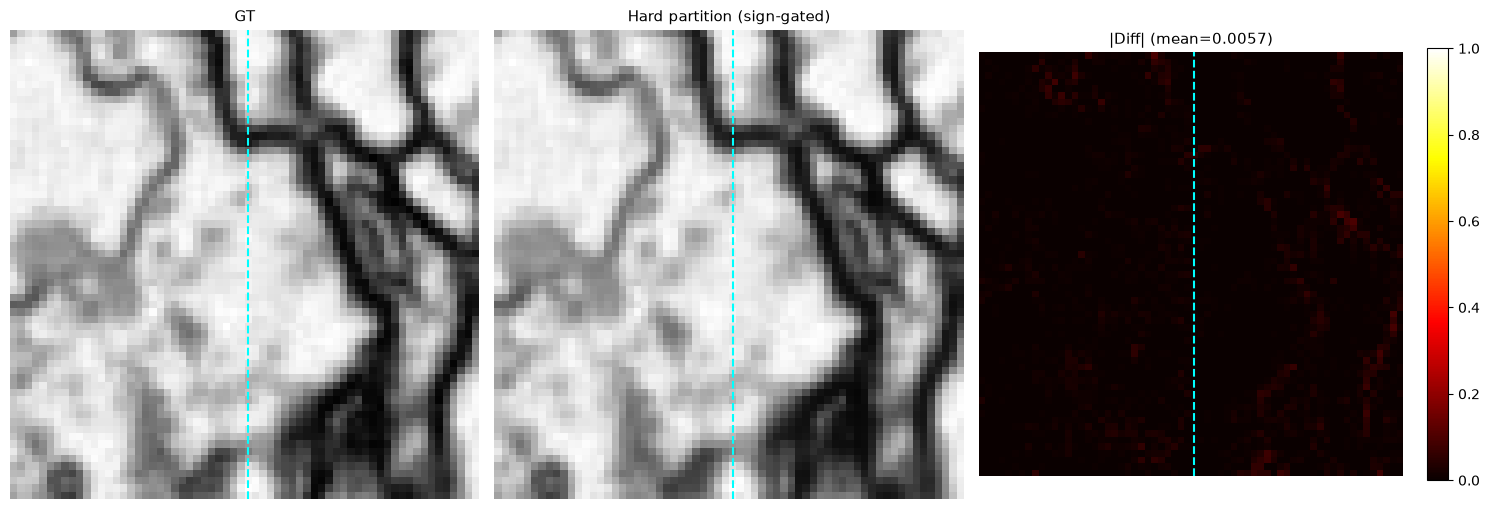

In [ ]:
# Hard partition, standalone view (recon_partition/diff_partition computed
# in the cell above, alongside naive sum and feathered blend for comparison).
diff_partition = np.abs(gt_cube_full[pmid] - recon_partition[pmid])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
imgs = [gt_cube_full[pmid], recon_partition[pmid], diff_partition]
titles = ["GT", "Hard partition (sign-gated)", f"|Diff| (mean={diff_partition.mean():.4f})"]
for ax, img, title, is_diff in zip(axes, imgs, titles, [False, False, True]):
    ax.imshow(img, cmap='hot' if is_diff else 'gray', vmin=0, vmax=1)
    ax.axvline(32, color='cyan', linestyle='--')
    ax.set_title(title, fontsize=11)
    if is_diff:
        # add color bar for the diff plot
        plt.colorbar(ax.imshow(img, cmap='hot', vmin=0, vmax=1), ax=ax, fraction=0.046)
    ax.axis('off')
plt.tight_layout()
plt.savefig("/root/project/fafb_pilot/code/representation/figures/seam_hard_partition.pdf", dpi=800, bbox_inches='tight')
plt.show()


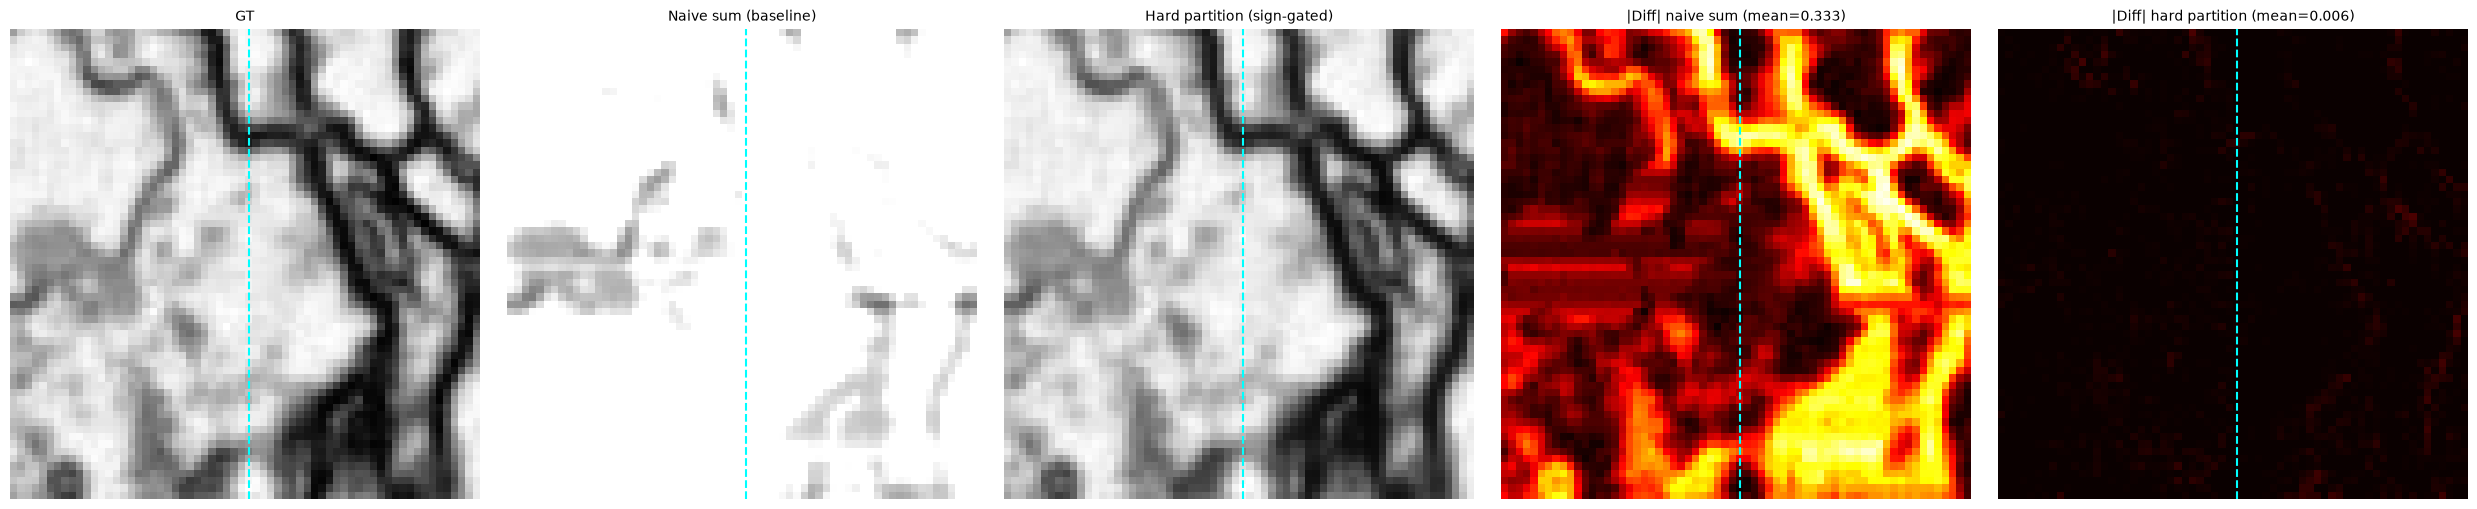

|Diff| naive sum      : mean=0.3329  max=0.9822
|Diff| hard partition : mean=0.0057  max=0.0954


In [ ]:
# Combined figure for the paper (Experiments.docx Figure 2): merges the
# comparison above with this cell's addition -- the hard partition's OWN
# |Diff| map, which the 4-panel version doesn't show (it only shows |Diff|
# for the naive sum). Five panels: GT, Naive sum, Hard partition, |Diff|
# naive sum, |Diff| hard partition -- lets a reader compare both combiners'
# error patterns directly, side by side, against the same GT.
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
imgs = [gt_cube_full[pmid], recon_sum[pmid], recon_partition[pmid], diff_sum, diff_partition]
titles = ["GT", "Naive sum (baseline)", "Hard partition (sign-gated)",
          f"|Diff| naive sum (mean={diff_sum.mean():.3f})",
          f"|Diff| hard partition (mean={diff_partition.mean():.3f})"]
is_diff_flags = [False, False, False, True, True]
for ax, img, title, is_diff in zip(axes, imgs, titles, is_diff_flags):
    ax.imshow(img, cmap='hot' if is_diff else 'gray', vmin=0, vmax=1)
    ax.axvline(32, color='cyan', linestyle='--')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig("/root/project/fafb_pilot/code/representation/figures/seam_figure2_combined.pdf",
            dpi=800, bbox_inches='tight')
plt.show()

print(f"|Diff| naive sum      : mean={diff_sum.mean():.4f}  max={diff_sum.max():.4f}")
print(f"|Diff| hard partition : mean={diff_partition.mean():.4f}  max={diff_partition.max():.4f}")


In [39]:
# Beyond vol_PSNR: since neither SSIM nor LPIPS has a native 3D formulation,
# both are defined here as the mean of the standard 2D metric computed
# independently over every Z-slice of the 64^3 seam cube, then averaged --
# same "whole-volume" spirit as vol_psnr above, adapted to metrics that only
# exist in 2D. LPIPS (net='alex') needs 3-channel input in [-1,1]; our
# grayscale slices are replicated to 3 channels and rescaled from [0,1],
# same convention as train_stitched_neighborhood.py.
from skimage.metrics import structural_similarity
import lpips as lpips_pkg

lpips_model = lpips_pkg.LPIPS(net='alex').to(device)
lpips_model.eval()

def vol_ssim(pred_cube, gt_cube):
    """Mean SSIM over every Z-slice of a (D,H,W) cube in [0,1]."""
    vals = [structural_similarity(gt_cube[z], pred_cube[z], data_range=1.0)
            for z in range(gt_cube.shape[0])]
    return float(np.mean(vals))

def vol_lpips(pred_cube, gt_cube, model, device):
    """Mean LPIPS (net='alex') over every Z-slice -- grayscale replicated to
    3 channels, rescaled [0,1] -> [-1,1] to match LPIPS's expected input
    range, same convention as train_stitched_neighborhood.py."""
    D = gt_cube.shape[0]
    vals = []
    with torch.no_grad():
        for z in range(D):
            gt_t = torch.from_numpy(gt_cube[z]).float().to(device)
            pred_t = torch.from_numpy(pred_cube[z]).float().to(device)
            gt_rgb = (gt_t.unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1) * 2 - 1)
            pred_rgb = (pred_t.unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1) * 2 - 1)
            vals.append(model(pred_rgb, gt_rgb).item())
    return float(np.mean(vals))

results = {}
for name, recon_arr in [("Naive additive sum", recon_sum),
                         ("Hard partition (sign-gated)", recon_partition)]:
    results[name] = {
        "vol_PSNR": vol_psnr(recon_arr, gt_cube_full),
        "vol_SSIM": vol_ssim(recon_arr, gt_cube_full),
        "vol_LPIPS": vol_lpips(recon_arr, gt_cube_full, lpips_model, device),
    }

for name, m in results.items():
    print(f"{name:30s}  vol_PSNR={m['vol_PSNR']:6.3f} dB   "
          f"vol_SSIM={m['vol_SSIM']:.4f}   vol_LPIPS={m['vol_LPIPS']:.4f}")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


Loading model from: /venv/r3-ml/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
Naive additive sum              vol_PSNR= 7.635 dB   vol_SSIM=0.3577   vol_LPIPS=0.3913
Hard partition (sign-gated)     vol_PSNR=39.963 dB   vol_SSIM=0.9977   vol_LPIPS=0.0012


## 4.5 Generalizing to Higher-Order Junctions: 4-Block and 8-Block Corners

Section 4 characterised the artefact at a single pairwise seam — 2 blocks
meeting along one axis (X). Real stitching junctions are frequently
higher-order: a shared **edge** where 4 blocks meet (2 axes simultaneously,
e.g. an XY corner within one Z-layer), or a shared **corner** where 8 blocks
meet (all 3 axes simultaneously, a full 2×2×2 neighbourhood). This section
repeats the same naive-sum vs. hard-partition comparison (vol_PSNR /
vol_SSIM / vol_LPIPS), on a 64³ cube built the same way as Section 4's seam
cube, but generalised from 1 split axis to 2 and then 3.

**4-block junction (XY corner, fixed Z).** `b_211`, `b_212`, `b_221`, `b_222`
— the 2×2 neighbourhood of `b_211` along Y and X, all sharing `iz=2`.

**8-block junction (XYZ corner).** The same 4 blocks plus their `iz=3`
counterparts `b_311`, `b_312`, `b_321`, `b_322` — a full 2×2×2 neighbourhood.

Both use exactly the pilot grid's `b_<iz><iy><ix>` → `image_z{30+iz}_y{30+iy}_x{30+ix}.tif`
mapping established in Section 1–2.


In [40]:
# Shared machinery for N-way junction experiments (N=4: XY corner within one
# Z-layer; N=8: full XYZ corner). Generalises cell 59c92fdd's 2-block seam
# construction: each block contributes its own NATIVE half (32 of its own 64
# voxels -- the half adjacent to the shared boundary) along every SPLIT
# axis, and its FULL native range along any axis that isn't split for this
# junction (e.g. Z is unsplit for the 4-block XY-corner case). Coordinates
# off a block's own half are zero-padded placeholders, exactly as in cell
# 59c92fdd -- kept identical here for methodological consistency with the
# already-reported 2-block numbers, rather than re-deriving the mapping.
half = cube // 2  # cube=64, defined in cell 59c92fdd

def axis_coord_and_mask(side, device):
    """side='low'  -> this block owns combined-index [0,half), native [half,cube).
       side='high' -> this block owns combined-index [half,cube), native [0,half).
       side=None   -> axis not split for this junction: full native range, mask all True."""
    j = torch.arange(cube, dtype=torch.float32, device=device)
    if side is None:
        return j / (cube - 1) * 2 - 1, torch.ones(cube, dtype=torch.bool, device=device)
    if side == 'low':
        mask = j < half
        coord = torch.where(mask, (j + half) / (cube - 1) * 2 - 1, torch.zeros_like(j))
    else:
        mask = j >= half
        coord = torch.where(mask, (j - half) / (cube - 1) * 2 - 1, torch.zeros_like(j))
    return coord, mask

def native_gt_slice(side):
    """Which half of a block's OWN 64-voxel GT array feeds this junction cube."""
    if side is None:
        return slice(0, cube)
    return slice(half, cube) if side == 'low' else slice(0, half)

def cube_slice(side):
    """Which half of the COMBINED junction cube this block's contribution lands in."""
    if side is None:
        return slice(0, cube)
    return slice(0, half) if side == 'low' else slice(half, cube)

def parse_block_name(bname):
    digits = bname.split('_')[1]
    return int(digits[0]), int(digits[1]), int(digits[2])  # iz, iy, ix

def load_block(bname, aabb, device):
    iz, iy, ix = parse_block_name(bname)
    ckpt = torch.load(f'/root/project/fafb_pilot/models/blocks_v2/{bname}/best.pth',
                       map_location='cpu', weights_only=False)
    gc = make_gc_native(ckpt, aabb, device)
    gt = normalize01(tiffile.imread(
        f'/root/project/data/fafb/blocks/image_z{30+iz}_y{30+iy}_x{30+ix}.tif'))
    return gc, gt

def run_junction_experiment(specs, device):
    """specs: list of dicts {'name': bname, 'z': side_or_None, 'y': side, 'x': side},
    one per block, covering the junction exhaustively with no overlap.
    Returns gt_cube, recon_sum, recon_partition -- all (64,64,64) numpy arrays."""
    gt_cube = np.empty((cube, cube, cube), dtype=np.float32)
    f_blocks, masks = [], []
    for spec in specs:
        gc, gt = load_block(spec['name'], aabb, device)
        zcoord, zmask = axis_coord_and_mask(spec.get('z'), device)
        ycoord, ymask = axis_coord_and_mask(spec.get('y'), device)
        xcoord, xmask = axis_coord_and_mask(spec.get('x'), device)
        zz, yy, xx = torch.meshgrid(zcoord, ycoord, xcoord, indexing='ij')
        pts = torch.stack([xx, yy, zz], dim=-1).reshape(-1, 3)
        with torch.no_grad():
            f = gc.forward(pts, chunk_n=128).reshape(cube, cube, cube)
        mask = (zmask.view(cube, 1, 1) & ymask.view(1, cube, 1) & xmask.view(1, 1, cube))
        f_blocks.append(f)
        masks.append(mask)

        gz = native_gt_slice(spec.get('z')); gy = native_gt_slice(spec.get('y')); gx = native_gt_slice(spec.get('x'))
        cz = cube_slice(spec.get('z'));      cy = cube_slice(spec.get('y'));      cx = cube_slice(spec.get('x'))
        gt_cube[cz, cy, cx] = gt[gz, gy, gx]

    recon_sum = torch.clamp(sum(f_blocks), 0, 1).cpu().numpy()
    partition = torch.zeros_like(f_blocks[0])
    for f, m in zip(f_blocks, masks):
        partition = torch.where(m, f, partition)
    recon_partition = torch.clamp(partition, 0, 1).cpu().numpy()
    return gt_cube, recon_sum, recon_partition

def report_junction_metrics(gt_cube, recon_sum, recon_partition, label):
    results = {}
    for name, cube_arr in [("Naive additive sum", recon_sum), ("Hard partition (sign-gated)", recon_partition)]:
        results[name] = {
            "vol_PSNR": vol_psnr(cube_arr, gt_cube),
            "vol_SSIM": vol_ssim(cube_arr, gt_cube),
            "vol_LPIPS": vol_lpips(cube_arr, gt_cube, lpips_model, device),
        }
    print(f"--- {label} ---")
    for name, m in results.items():
        print(f"{name:30s}  vol_PSNR={m['vol_PSNR']:6.3f} dB   "
              f"vol_SSIM={m['vol_SSIM']:.4f}   vol_LPIPS={m['vol_LPIPS']:.4f}")
    return results

def plot_junction_result(gt_cube, recon_sum, recon_partition, title_prefix, savepath):
    pmid = cube // 2
    diff_sum = np.abs(gt_cube[pmid] - recon_sum[pmid])
    diff_partition = np.abs(gt_cube[pmid] - recon_partition[pmid])
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    imgs = [gt_cube[pmid], recon_sum[pmid], recon_partition[pmid], diff_sum, diff_partition]
    titles = ["GT", "Naive sum (baseline)", "Hard partition (sign-gated)",
              f"|Diff| naive sum (mean={diff_sum.mean():.3f})",
              f"|Diff| hard partition (mean={diff_partition.mean():.3f})"]
    is_diff_flags = [False, False, False, True, True]
    for ax, img, ttl, is_diff in zip(axes, imgs, titles, is_diff_flags):
        ax.imshow(img, cmap='hot' if is_diff else 'gray', vmin=0, vmax=1)
        ax.axhline(half, color='cyan', linestyle='--', linewidth=1)
        ax.axvline(half, color='cyan', linestyle='--', linewidth=1)
        ax.set_title(ttl, fontsize=10)
        ax.axis('off')
    fig.suptitle(title_prefix, fontsize=13)
    plt.tight_layout()
    plt.savefig(savepath, dpi=800, bbox_inches='tight')
    plt.show()
    return diff_sum, diff_partition


--- 4-block XY-corner junction (b_211 / b_212 / b_221 / b_222) ---
Naive additive sum              vol_PSNR= 6.066 dB   vol_SSIM=0.0761   vol_LPIPS=0.8036
Hard partition (sign-gated)     vol_PSNR=39.948 dB   vol_SSIM=0.9974   vol_LPIPS=0.0014


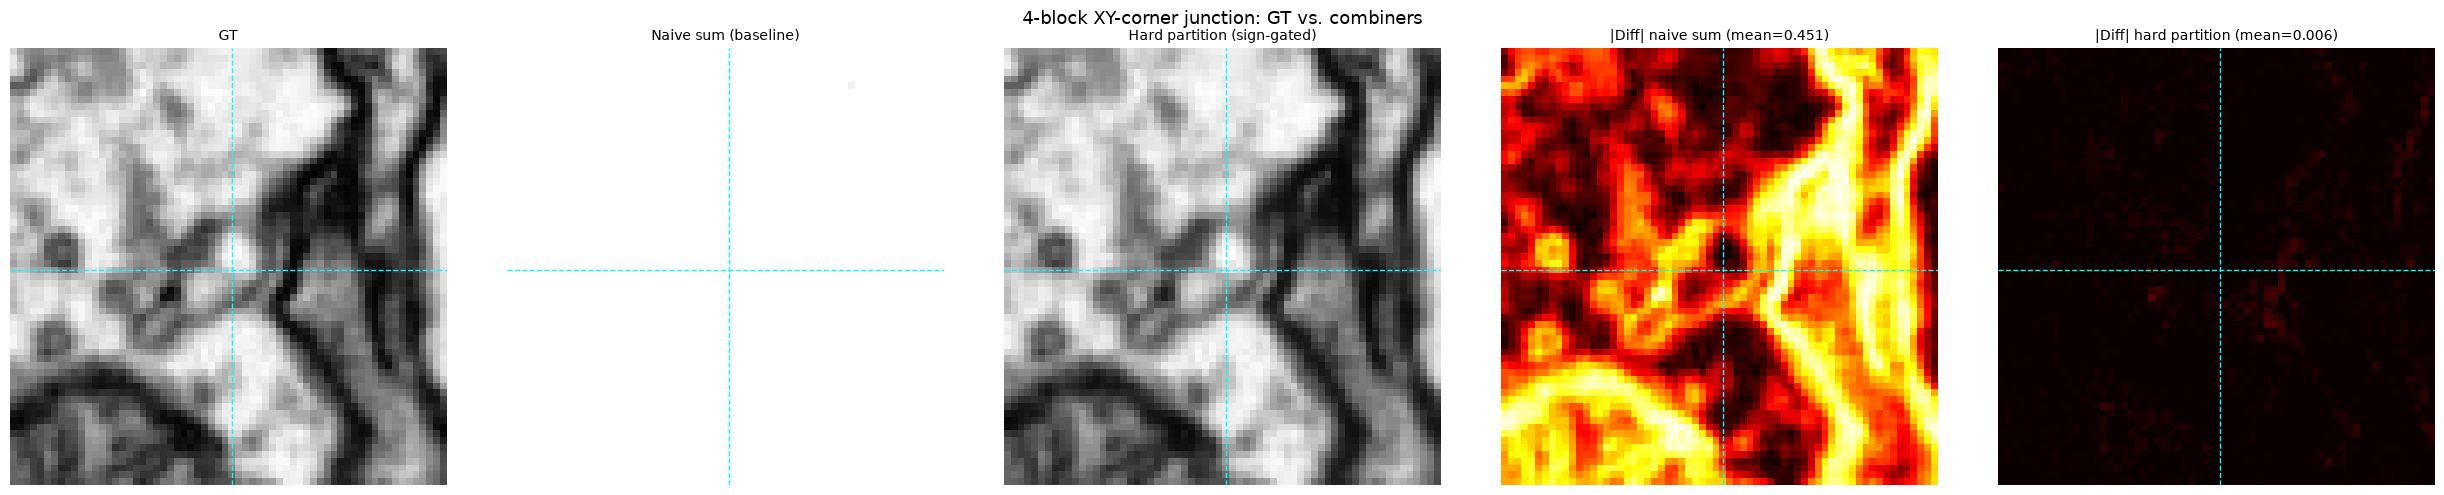

In [41]:
# 4-block junction: the 2x2 XY-neighbourhood of b_211, all sharing iz=2.
# Z is NOT split (all four blocks occupy the same Z range), so only y/x
# sides are specified per block.
specs_4block = [
    dict(name='b_211', y='low',  x='low'),
    dict(name='b_212', y='low',  x='high'),
    dict(name='b_221', y='high', x='low'),
    dict(name='b_222', y='high', x='high'),
]

gt_cube_4, recon_sum_4, recon_partition_4 = run_junction_experiment(specs_4block, device)
results_4block = report_junction_metrics(
    gt_cube_4, recon_sum_4, recon_partition_4,
    "4-block XY-corner junction (b_211 / b_212 / b_221 / b_222)")
diff_sum_4, diff_partition_4 = plot_junction_result(
    gt_cube_4, recon_sum_4, recon_partition_4,
    "4-block XY-corner junction: GT vs. combiners",
    "/root/project/fafb_pilot/code/representation/figures/junction4_combiners.pdf")


In [ ]:
# 8-block junction: the full 2x2x2 XYZ-neighbourhood of b_211 -- the 4
# blocks above (iz=2) plus their iz=3 counterparts. All three axes are now
# split.
specs_8block = [
    dict(name='b_211', z='low',  y='low',  x='low'),
    dict(name='b_212', z='low',  y='low',  x='high'),
    dict(name='b_221', z='low',  y='high', x='low'),
    dict(name='b_222', z='low',  y='high', x='high'),
    dict(name='b_311', z='high', y='low',  x='low'),
    dict(name='b_312', z='high', y='low',  x='high'),
    dict(name='b_321', z='high', y='high', x='low'),
    dict(name='b_322', z='high', y='high', x='high'),
]

gt_cube_8, recon_sum_8, recon_partition_8 = run_junction_experiment(specs_8block, device)
results_8block = report_junction_metrics(
    gt_cube_8, recon_sum_8, recon_partition_8,
    "8-block XYZ-corner junction (2x2x2 neighbourhood of b_211)")
diff_sum_8, diff_partition_8 = plot_junction_result(
    gt_cube_8, recon_sum_8, recon_partition_8,
    "8-block XYZ-corner junction: GT vs. combiners",
    "/root/project/fafb_pilot/code/representation/figures/junction8_combiners.pdf")


## 5. SVRaster-Style Rendering: Methodology and Baseline FPS

Switching tools: instead of the analytic Gaussian-mixture evaluation used
above, render a reconstructed voxel grid the way SVRaster (Sparse Voxels
Rasterization, arXiv 2412.04459, CVPR 2025) does — ray-marching with
trilinear-interpolated density lookups, composited via MIP (max along each
ray), matching this project's own established MIP convention. This
establishes the rendering method and its baseline FPS on `pred_stitch` (the
clean, negative-control naive-concat cube from Section 1–2), before using
the same renderer to re-examine the *real* artefact in Section 7.


In [ ]:
# SVRaster-style rasterization applied to OUR OWN dense voxel grid, to check
# its FPS. Paper: "Sparse Voxels Rasterization: Real-time High-fidelity
# Radiance Field Rendering" (arXiv 2412.04459, CVPR 2025), code:
# github.com/NVlabs/svraster.
#
# Their representation: sparse voxels in an octree, each storing a
# trilinearly-interpolated density field via 8 shared corner values (+ SH
# colour), rendered by marching K sample points through each voxel a ray
# passes through, with Morton-order depth sorting across octree levels to
# avoid popping artefacts.
#
# We do NOT have their octree/CUDA kernel or camera-posed 2D training data
# (our data is a direct 3D volume) -- but we DO have exactly the artefact
# their trilinear-interpolated corner densities describe: a plain dense
# voxel grid. So the part of their method we reproduce and time is the ray
# marching + per-sample trilinear density lookup; compositing is MIP (max
# over samples along each ray) instead of their alpha-compositing, to match
# this project's own established MIP convention (render_camera.py /
# sliding_window_camera.py / Mip_Render_Inside_Volume.cu all use MIP) rather
# than mixing two different compositing conventions in one comparison.
#
# This is a plain PyTorch prototype, not their hand-written CUDA kernel, so
# the FPS below reflects the rendering ALGORITHM's cost on our data, not an
# apples-to-apples engineering comparison against their optimised build.
import time
import torch.nn.functional as F

def svraster_style_render(vol, cam_pos, cam_target, up, fov_deg, img_size, n_steps, device):
    """vol: (D,H,W) tensor. Ray-marched with trilinear-interpolated density
    lookups (as in SVRaster), composited via MIP (max along each ray)."""
    D, H, W = vol.shape
    vol5 = vol.view(1, 1, D, H, W).to(device)

    forward = cam_target - cam_pos
    forward = forward / forward.norm()
    right = torch.cross(forward, up, dim=0)
    right = right / right.norm()
    true_up = torch.cross(right, forward, dim=0)

    fov = np.radians(fov_deg)
    ys, xs = torch.meshgrid(
        torch.linspace(1, -1, img_size, device=device),
        torch.linspace(-1, 1, img_size, device=device),
        indexing='ij')
    dirs = (xs.unsqueeze(-1) * np.tan(fov / 2) * right
            + ys.unsqueeze(-1) * np.tan(fov / 2) * true_up
            + forward)
    dirs = dirs / dirs.norm(dim=-1, keepdim=True)  # (img_size, img_size, 3)

    t_vals = torch.linspace(0.0, 3.0, n_steps, device=device)  # covers the [-1,1]^3 cube from outside

    # (img_size, img_size, n_steps, 3) sample points along each ray
    pts = cam_pos.view(1, 1, 1, 3) + dirs.unsqueeze(2) * t_vals.view(1, 1, n_steps, 1)
    grid = pts.unsqueeze(0)  # grid_sample 5D convention: (N, D_out, H_out, W_out, 3), last dim = (x,y,z)

    sigma = F.grid_sample(vol5, grid, mode='bilinear', padding_mode='zeros', align_corners=True)
    sigma = sigma.view(img_size, img_size, n_steps).clamp(min=0)

    colour = sigma.max(dim=-1).values  # MIP: max density along each ray
    return colour.clamp(0, 1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vol_test = torch.from_numpy(pred_stitch).float()  # our own already-reconstructed voxel grid, (64,64,64)
img_size, n_steps, n_frames = 256, 96, 24
azimuths = np.linspace(0, 360, n_frames, endpoint=False)
up = torch.tensor([0., 1., 0.], device=device)
target = torch.tensor([0., 0., 0.], device=device)

frames, times = [], []
for az in azimuths:
    theta = np.radians(az)
    cam_pos = torch.tensor([2.5 * np.sin(theta), 0.0, 2.5 * np.cos(theta)], device=device, dtype=torch.float32)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        img = svraster_style_render(vol_test, cam_pos, target, up, fov_deg=50,
                                     img_size=img_size, n_steps=n_steps, device=device)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    times.append(time.perf_counter() - t0)
    frames.append(img.cpu().numpy())

times = np.array(times)
print(f"SVRaster-style ray-march render (MIP): {n_frames} frames @ {img_size}x{img_size}, {n_steps} samples/ray")
print(f"avg {times.mean()*1000:.2f} ms/frame -> {1.0/times.mean():.2f} FPS "
      f"(min {times.min()*1000:.2f} / max {times.max()*1000:.2f} ms)")
print(f"(paper's reported SVRaster FPS on an RTX 3090 Ti: 240/137/92 for small/base/large variants)")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i in zip(axes, np.linspace(0, n_frames - 1, 4).astype(int)):
    ax.imshow(frames[i], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"az={azimuths[i]:.0f}°")
    ax.axis('off')
plt.tight_layout()
plt.savefig("/root/project/fafb_pilot/code/representation/figures/svraster_style_render.pdf", dpi=800)
plt.show()


SVRaster-style ray-march render (MIP): 24 frames @ 256x256, 96 samples/ray
avg 1.96 ms/frame -> 511.46 FPS (min 1.16 / max 19.25 ms)
(paper's reported SVRaster FPS on an RTX 3090 Ti: 240/137/92 for small/base/large variants)


/tmp/ipykernel_2507948/1707039785.py:97: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 6. GT vs. Reconstruction Under SVRaster-Style Rendering

Same renderer, same viewpoints, now on the GT volume as well — a visual
sanity check that the reconstruction (still `pred_stitch`, the clean
negative control) matches GT under this new rendering method too.


In [ ]:
# Same SVRaster-style DVR, same azimuths, now on the GT volume instead of
# the reconstruction -- image_z2_y1_x1 is the (correctly-normalised, see
# earlier cell) ground truth for b_211 (image_z32_y31_x31.tif). Lets us
# compare GT vs. reconstruction at matching viewpoints, and confirms FPS is
# unaffected by which volume is rendered (same grid size, same algorithm).
vol_gt = torch.from_numpy(gt_stitch).float()

frames_gt, times_gt = [], []
for az in azimuths:
    theta = np.radians(az)
    cam_pos = torch.tensor([2.5 * np.sin(theta), 0.0, 2.5 * np.cos(theta)], device=device, dtype=torch.float32)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        img = svraster_style_render(vol_gt, cam_pos, target, up, fov_deg=50,
                                     img_size=img_size, n_steps=n_steps, device=device)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    times_gt.append(time.perf_counter() - t0)
    frames_gt.append(img.cpu().numpy())

times_gt = np.array(times_gt)
print(f"SVRaster-style ray-march render (GT): {n_frames} frames @ {img_size}x{img_size}, {n_steps} samples/ray")
print(f"avg {times_gt.mean()*1000:.2f} ms/frame -> {1.0/times_gt.mean():.2f} FPS "
      f"(min {times_gt.min()*1000:.2f} / max {times_gt.max()*1000:.2f} ms)")

sample_idx = np.linspace(0, n_frames - 1, 4).astype(int)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for col, i in enumerate(sample_idx):
    diff_img = np.abs(frames_gt[i] - frames[i])
    axes[0, col].imshow(frames_gt[i], cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f"GT  az={azimuths[i]:.0f}°")
    axes[0, col].axis('off')
    axes[1, col].imshow(frames[i], cmap='gray', vmin=0, vmax=1)
    axes[1, col].set_title(f"Recon  az={azimuths[i]:.0f}°")
    axes[1, col].axis('off')
    im = axes[2, col].imshow(diff_img, cmap='hot', vmin=0, vmax=1)
    axes[2, col].set_title(f"|Diff|  az={azimuths[i]:.0f}°  (mean={diff_img.mean():.3f})")
    axes[2, col].axis('off')
fig.colorbar(im, ax=axes[2, :].tolist(), fraction=0.02, pad=0.01)
plt.savefig("/root/project/fafb_pilot/code/representation/figures/svraster_style_render_gt_vs_recon.pdf", dpi=800, bbox_inches='tight')
plt.show()


SVRaster-style ray-march render (GT): 24 frames @ 256x256, 96 samples/ray
avg 1.23 ms/frame -> 811.49 FPS (min 1.12 / max 2.58 ms)


/tmp/ipykernel_2507948/1632148213.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Does the Real Artefact Survive Under SVRaster-Style (MIP) Rendering?

Section 4 established the artefact quantitatively via direct analytic
evaluation. This section asks whether it's also visible through an actual
rendering pipeline — using `seam_gt`/`seam_recon` (the real GT and the real
naive-additive-sum reconstruction from `seam_cube.py`, loaded in Section 3),
not the clean negative-control arrays used in Sections 5–6.


## 8. Standalone View: SVRaster-Style Render of the Real Naive-Sum Seam Cube

Same rendering method, focused purely on the real artefact's reconstruction
(`seam_recon_t`, now correctly the naive-additive-sum cube from Section 3/7)
across a full orbit — is the white-out band visible from every angle, or
only face-on?


In [ ]:
# Apply the same SVRaster-style (MIP) renderer to the 64^3 SEAM cube
# straddling b_211/b_212 -- seam_gt / seam_recon (loaded in Section 3 from
# seam_cube.py's output) are the REAL ground truth and the REAL naive-
# additive stitched reconstruction (vol_PSNR=7.64dB per Section 4's
# corrected measurement), NOT the clean negative-control gt_stitch/
# pred_stitch used in Sections 5-6. Question: does the double-counting
# artefact survive being viewed through an orbiting MIP render?
seam_gt_t = torch.from_numpy(seam_gt).float()
seam_recon_t = torch.from_numpy(seam_recon).float()

seam_frames_gt, seam_frames_recon = [], []
for az in azimuths:
    theta = np.radians(az)
    cam_pos = torch.tensor([2.5 * np.sin(theta), 0.0, 2.5 * np.cos(theta)], device=device, dtype=torch.float32)
    with torch.no_grad():
        img_gt = svraster_style_render(seam_gt_t, cam_pos, target, up, fov_deg=50,
                                        img_size=img_size, n_steps=n_steps, device=device)
        img_recon = svraster_style_render(seam_recon_t, cam_pos, target, up, fov_deg=50,
                                           img_size=img_size, n_steps=n_steps, device=device)
    seam_frames_gt.append(img_gt.cpu().numpy())
    seam_frames_recon.append(img_recon.cpu().numpy())

# Also render face-on along the seam axis (X): camera looking straight down
# +X, i.e. straight through the seam plane -- the view most likely to catch
# the artefact, since every ray along this direction crosses the boundary.
cam_pos_faceon = torch.tensor([2.5, 0.0, 0.0], device=device, dtype=torch.float32)
up_faceon = torch.tensor([0., 1., 0.], device=device)
with torch.no_grad():
    faceon_gt = svraster_style_render(seam_gt_t, cam_pos_faceon, target, up_faceon, fov_deg=50,
                                       img_size=img_size, n_steps=n_steps, device=device).cpu().numpy()
    faceon_recon = svraster_style_render(seam_recon_t, cam_pos_faceon, target, up_faceon, fov_deg=50,
                                          img_size=img_size, n_steps=n_steps, device=device).cpu().numpy()

sample_idx = np.linspace(0, n_frames - 1, 3).astype(int)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
titles_extra = [f"az={azimuths[i]:.0f}°" for i in sample_idx] + ["face-on (looking down +X)"]
gt_imgs = [seam_frames_gt[i] for i in sample_idx] + [faceon_gt]
recon_imgs = [seam_frames_recon[i] for i in sample_idx] + [faceon_recon]
for col, (title, gt_img, recon_img) in enumerate(zip(titles_extra, gt_imgs, recon_imgs)):
    diff_img = np.abs(gt_img - recon_img)
    axes[0, col].imshow(gt_img, cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f"GT  {title}")
    axes[0, col].axis('off')
    axes[1, col].imshow(recon_img, cmap='gray', vmin=0, vmax=1)
    axes[1, col].set_title(f"Naive-sum recon  {title}")
    axes[1, col].axis('off')
    im = axes[2, col].imshow(diff_img, cmap='hot', vmin=0, vmax=1)
    axes[2, col].set_title(f"|Diff|  mean={diff_img.mean():.3f}  max={diff_img.max():.3f}")
    axes[2, col].axis('off')
fig.colorbar(im, ax=axes[2, :].tolist(), fraction=0.02, pad=0.01)
plt.savefig("/root/project/fafb_pilot/code/representation/figures/svraster_seam_mip.pdf", dpi=800, bbox_inches='tight')
plt.show()

print("Seam MIP |diff| across the full orbit (24 views):")
orbit_diffs = [np.abs(g - r).mean() for g, r in zip(seam_frames_gt, seam_frames_recon)]
print(f"  mean over orbit = {np.mean(orbit_diffs):.4f}   max over orbit = {np.max(orbit_diffs):.4f}")
print(f"  face-on view mean|diff| = {np.abs(faceon_gt - faceon_recon).mean():.4f}")


Seam MIP |diff| across the full orbit (24 views):
  mean over orbit = 0.0456   max over orbit = 0.0589
  face-on view mean|diff| = 0.0546


/tmp/ipykernel_2507948/174622411.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
# Standalone SVRaster-style (MIP) orbit render of the 64^3 cube sitting
# BETWEEN b_211 and b_212 -- i.e. seam_recon itself (the naive-additive
# stitched reconstruction at the seam), rendered the same way b211 was
# rendered on its own earlier (cell 3f1eb58d): FPS + a 4-view orbit grid,
# no diff/GT comparison this time, just "what does SVRaster-style DVR of
# this in-between cube look like".
seam_frames, seam_times = [], []
for az in azimuths:
    theta = np.radians(az)
    cam_pos = torch.tensor([2.5 * np.sin(theta), 0.0, 2.5 * np.cos(theta)], device=device, dtype=torch.float32)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        img = svraster_style_render(seam_recon_t, cam_pos, target, up, fov_deg=50,
                                     img_size=img_size, n_steps=n_steps, device=device)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    seam_times.append(time.perf_counter() - t0)
    seam_frames.append(img.cpu().numpy())

seam_times = np.array(seam_times)
print(f"SVRaster-style ray-march render (in-between b_211|b_212 cube): "
      f"{n_frames} frames @ {img_size}x{img_size}, {n_steps} samples/ray")
print(f"avg {seam_times.mean()*1000:.2f} ms/frame -> {1.0/seam_times.mean():.2f} FPS "
      f"(min {seam_times.min()*1000:.2f} / max {seam_times.max()*1000:.2f} ms)")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i in zip(axes, np.linspace(0, n_frames - 1, 4).astype(int)):
    ax.imshow(seam_frames[i], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"az={azimuths[i]:.0f}°")
    ax.axis('off')
fig.suptitle("SVRaster-style MIP render of the 64³ cube between b_211 and b_212\n"
             "(naive-additive stitched reconstruction)", fontsize=12)
plt.tight_layout()
plt.savefig("/root/project/fafb_pilot/code/representation/figures/svraster_style_render_inbetween_cube.pdf",
            dpi=800, bbox_inches='tight')
plt.show()


SVRaster-style ray-march render (in-between b_211|b_212 cube): 24 frames @ 256x256, 96 samples/ray
avg 1.01 ms/frame -> 994.35 FPS (min 0.96 / max 1.67 ms)


/tmp/ipykernel_2507948/2611710926.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 9. SVRaster (MIP) vs. Classic DVR: FPS at Larger Scale

Separate from the stitching question — checks whether the FPS gap between
MIP and alpha-compositing DVR (established in Section 5) holds at a larger
grid size (`fafb_pilot_256.h5`, 256³ vs. the 64³ blocks used throughout).


In [ ]:
# SVRaster-style (MIP) vs. classic DVR (alpha-compositing) FPS comparison,
# both on the same larger volume: fafb_pilot/data/fafb_pilot_256.h5 (256^3,
# vs. the 64^3 blocks used everywhere above) -- checks whether the FPS gap
# between the two compositing schemes (MIP: max along ray, no transmittance
# recurrence; DVR: alpha-blend with T_i = prod(1-alpha_j)) holds up at a
# larger grid size, and whether either becomes camera/grid-size bound here.
import h5py

with h5py.File('/root/project/fafb_pilot/data/fafb_pilot_256.h5', 'r') as f:
    raw_256 = f['raw'][:]
vol_256 = normalize01(raw_256)  # uint8 [0,255] -> [0,1], same convention as everywhere else
vol_256_t = torch.from_numpy(vol_256).float()
print(f"fafb_pilot_256.h5: shape={vol_256.shape}  range=[{vol_256.min():.3f}, {vol_256.max():.3f}]")

def dvr_alpha_composite_render(vol, cam_pos, cam_target, up, fov_deg, img_size, n_steps, device):
    """Classic Direct Volume Rendering: same ray marching + trilinear density
    lookup as svraster_style_render, but composited via alpha-blending
    (transmittance-weighted accumulation) instead of MIP."""
    D, H, W = vol.shape
    vol5 = vol.view(1, 1, D, H, W).to(device)

    forward = cam_target - cam_pos
    forward = forward / forward.norm()
    right = torch.cross(forward, up, dim=0)
    right = right / right.norm()
    true_up = torch.cross(right, forward, dim=0)

    fov = np.radians(fov_deg)
    ys, xs = torch.meshgrid(
        torch.linspace(1, -1, img_size, device=device),
        torch.linspace(-1, 1, img_size, device=device),
        indexing='ij')
    dirs = (xs.unsqueeze(-1) * np.tan(fov / 2) * right
            + ys.unsqueeze(-1) * np.tan(fov / 2) * true_up
            + forward)
    dirs = dirs / dirs.norm(dim=-1, keepdim=True)

    t_vals = torch.linspace(0.0, 3.0, n_steps, device=device)
    step_size = float(t_vals[1] - t_vals[0])

    pts = cam_pos.view(1, 1, 1, 3) + dirs.unsqueeze(2) * t_vals.view(1, 1, n_steps, 1)
    grid = pts.unsqueeze(0)

    sigma = F.grid_sample(vol5, grid, mode='bilinear', padding_mode='zeros', align_corners=True)
    sigma = sigma.view(img_size, img_size, n_steps).clamp(min=0)

    alpha = 1.0 - torch.exp(-sigma * step_size)
    T = torch.cumprod(torch.cat([torch.ones_like(alpha[..., :1]), 1 - alpha + 1e-10], dim=-1), dim=-1)[..., :-1]
    weights = T * alpha
    colour = (weights * sigma).sum(-1)
    return colour.clamp(0, 1)

def bench_renderer(render_fn, vol, azimuths, img_size, n_steps, device):
    frames_, times_ = [], []
    for az in azimuths:
        theta = np.radians(az)
        cam_pos = torch.tensor([2.5 * np.sin(theta), 0.0, 2.5 * np.cos(theta)], device=device, dtype=torch.float32)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            img = render_fn(vol, cam_pos, target, up, fov_deg=50, img_size=img_size, n_steps=n_steps, device=device)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        times_.append(time.perf_counter() - t0)
        frames_.append(img.cpu().numpy())
    return frames_, np.array(times_)

mip_frames_256, mip_times_256 = bench_renderer(svraster_style_render, vol_256_t, azimuths, img_size, n_steps, device)
dvr_frames_256, dvr_times_256 = bench_renderer(dvr_alpha_composite_render, vol_256_t, azimuths, img_size, n_steps, device)

print(f"\nOn fafb_pilot_256.h5 ({vol_256.shape[0]}^3), {n_frames} frames @ {img_size}x{img_size}, {n_steps} samples/ray:")
print(f"  SVRaster-style (MIP): avg {mip_times_256.mean()*1000:.2f} ms/frame -> {1.0/mip_times_256.mean():.2f} FPS")
print(f"  DVR (alpha-composite): avg {dvr_times_256.mean()*1000:.2f} ms/frame -> {1.0/dvr_times_256.mean():.2f} FPS")
print(f"  MIP speedup over DVR: {(1.0/mip_times_256.mean()) / (1.0/dvr_times_256.mean()):.2f}x")

sample_idx = np.linspace(0, n_frames - 1, 4).astype(int)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, i in enumerate(sample_idx):
    axes[0, col].imshow(mip_frames_256[i], cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f"MIP  az={azimuths[i]:.0f}°")
    axes[0, col].axis('off')
    axes[1, col].imshow(dvr_frames_256[i], cmap='gray', vmin=0, vmax=1)
    axes[1, col].set_title(f"DVR  az={azimuths[i]:.0f}°")
    axes[1, col].axis('off')
plt.suptitle("fafb_pilot_256.h5 (256³): SVRaster-style MIP vs. DVR alpha-compositing")
plt.tight_layout()
plt.savefig("/root/project/fafb_pilot/code/representation/figures/svraster_vs_dvr_256.pdf", dpi=800, bbox_inches='tight')
plt.show()


fafb_pilot_256.h5: shape=(256, 256, 256)  range=[0.000, 1.000]



On fafb_pilot_256.h5 (256^3), 24 frames @ 256x256, 96 samples/ray:
  SVRaster-style (MIP): avg 6.29 ms/frame -> 159.05 FPS
  DVR (alpha-composite): avg 6.98 ms/frame -> 143.35 FPS
  MIP speedup over DVR: 1.11x


/tmp/ipykernel_2507948/4193640255.py:89: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Conclusion

**The artefact is real and severe.** Naively summing two independently-trained
blocks' Gaussian density fields at a shared boundary gives vol_PSNR ≈ **7.6 dB**
at the seam (`b_211`/`b_212`), versus ≈40.5 dB for either block evaluated
alone — not a subtle discontinuity but near-total saturation across a wide
region around the boundary (confirmed both by direct analytic evaluation,
Section 4, and by an independent SVRaster-style MIP render, Sections 7–8).

**Mechanism.** Each block's Gaussian *means* are correctly confined to their
own block (enforced every training step by `clamp_means()`), but nothing
clips the Gaussian *density function* at the boundary — a Gaussian near its
own edge legitimately has non-negligible density past it. Both blocks
correctly place real density at the same shared-frame location (measured
directly: 0.516 + 0.515 → 1.031 at the exact seam), and the production
pipeline sums instead of reconciling them.

**Fix.** A hard, sign-gated partition — for a given point, evaluate only the
Gaussians of whichever block owns that side of the seam, never summing
across the boundary — recovers **39.96 dB**, essentially the full per-block
native quality (~40.47 dB). A feathered (partition-of-unity) blend was also
tested and did *not* help at the tested bandwidth (8.80 dB, no better than
naive sum) — worth revisiting with a different band width/ramp if a smooth
transition (rather than a hard switch) is wanted for the final method.

**Caveat on rendering method.** Sections 5–9 confirm the artefact is not an
artifact of *how* the field is visualised — it shows up identically whether
evaluated analytically or rendered via MIP ray-marching (mean |diff| ≈0.046
across a 24-view orbit for the real naive-sum cube, vs. ≈0.001 for a clean
whole-block control) — so the fix needs to happen in the density
*combination* step, not in the choice of renderer.
